# O6 Multimodal — 25 dimensions
Fixed depths 5, 10, 15, 20, 30 and staged `3 → 6 → 9 → 20`.

In [11]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
if HERE.name != "03_more_dimensions":
    HERE = Path("/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o6_multi_modal/depth_policies/03_more_dimensions")
OUTPUT_DIRECTORY = HERE / "smac_output"
DIMENSION = 25
DEPTHS = (5, 10, 15, 20, 30)
FIXED = tuple(f"fixed_depth_{d}" for d in DEPTHS)
STAGED = "staged_depth_3_6_9_20"
POLICIES = FIXED + (STAGED,)
SEEDS = tuple(range(5))
N_TRIALS = 1800
CHECKPOINTS = tuple(range(100, N_TRIALS + 1, 100))
LABELS = {f"fixed_depth_{d}": f"depth = {d}" for d in DEPTHS}
LABELS[STAGED] = "staged 3 → 6 → 9 → 20"
COLORS = dict(zip(POLICIES, ("C0", "C1", "C2", "C3", "C4", "black")))

In [12]:
def load(policy):
    runs = {}
    for path in (OUTPUT_DIRECTORY / policy).rglob("trajectory.json"):
        result = json.loads(path.read_text())
        runhistory_path = path.with_name("runhistory.json")
        if not runhistory_path.exists():
            continue
        runhistory = json.loads(runhistory_path.read_text())
        trials = sorted(runhistory["data"], key=lambda trial: (trial["starttime"], trial["endtime"]))
        if len(trials) < N_TRIALS:
            continue
        objective_values = np.asarray([
            float(trial["cost"]) - result["instance_map"][trial["instance"]]
            for trial in trials[:N_TRIALS]
        ])
        result["iteration"] = list(range(1, N_TRIALS + 1))
        result["best_regret"] = np.minimum.accumulate(objective_values - result["f_min"]).tolist()
        result["n_trials"] = N_TRIALS
        if result["smac_seed"] in SEEDS:
            runs[result["smac_seed"]] = result
    missing = sorted(set(SEEDS) - set(runs))
    if missing: raise FileNotFoundError(f"Missing {policy}: seeds={missing}")
    return runs

results = {p: load(p) for p in POLICIES}
for policy, runs in results.items():
    for result in runs.values():
        assert result["problem"] == "O6-Multimodal"
        assert result["dimension"] == DIMENSION
        assert result["problem_seed"] == 52
        assert result["initial_design"] == "random"
        assert result["n_initial_configs"] == 10
        if policy in FIXED: assert result["max_depth"] == int(policy.rsplit("_", 1)[1])
        else:
            assert result["stage_boundaries"] == [100, 200, 500]
            assert result["depth_schedule"] == [3, 6, 9, 20]
print(f"Loaded {sum(map(len, results.values()))}/30 trajectories.")

Loaded 30/30 trajectories.


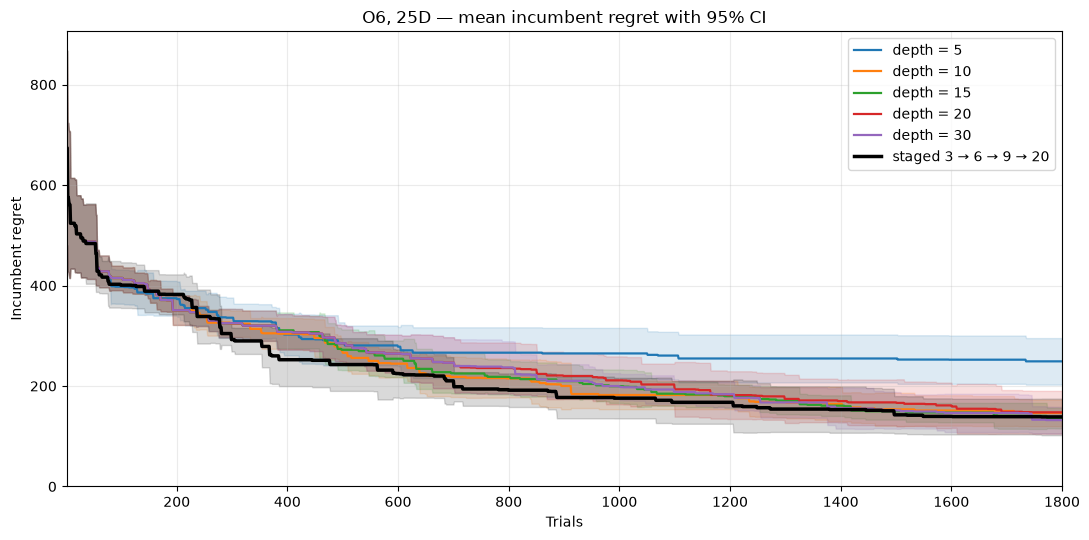

In [13]:
rows = [{"policy": p, "seed": s, "iteration": i, "best_regret": r} for p, runs in results.items() for s, result in runs.items() for i, r in zip(result["iteration"], result["best_regret"])]
trajectories = pd.DataFrame(rows)
summary = trajectories.groupby(["policy", "iteration"])["best_regret"].agg(["mean", "std", "count"]).reset_index()
summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["count"])
fig, ax = plt.subplots(figsize=(11, 5.5))
for p in POLICIES:
    d = summary[summary.policy == p]
    ax.plot(d.iteration, d["mean"], label=LABELS[p], color=COLORS[p], linewidth=2.5 if p == STAGED else 1.6)
    ax.fill_between(d.iteration, np.maximum(0, d["mean"]-d.ci95), d["mean"]+d.ci95, color=COLORS[p], alpha=.15)
ax.set(title=f"O6, {DIMENSION}D — mean incumbent regret with 95% CI", xlabel="Trials", ylabel="Incumbent regret", xlim=(1, N_TRIALS), ylim=(0,None)); ax.grid(alpha=.25); ax.legend(); plt.tight_layout(); plt.show()

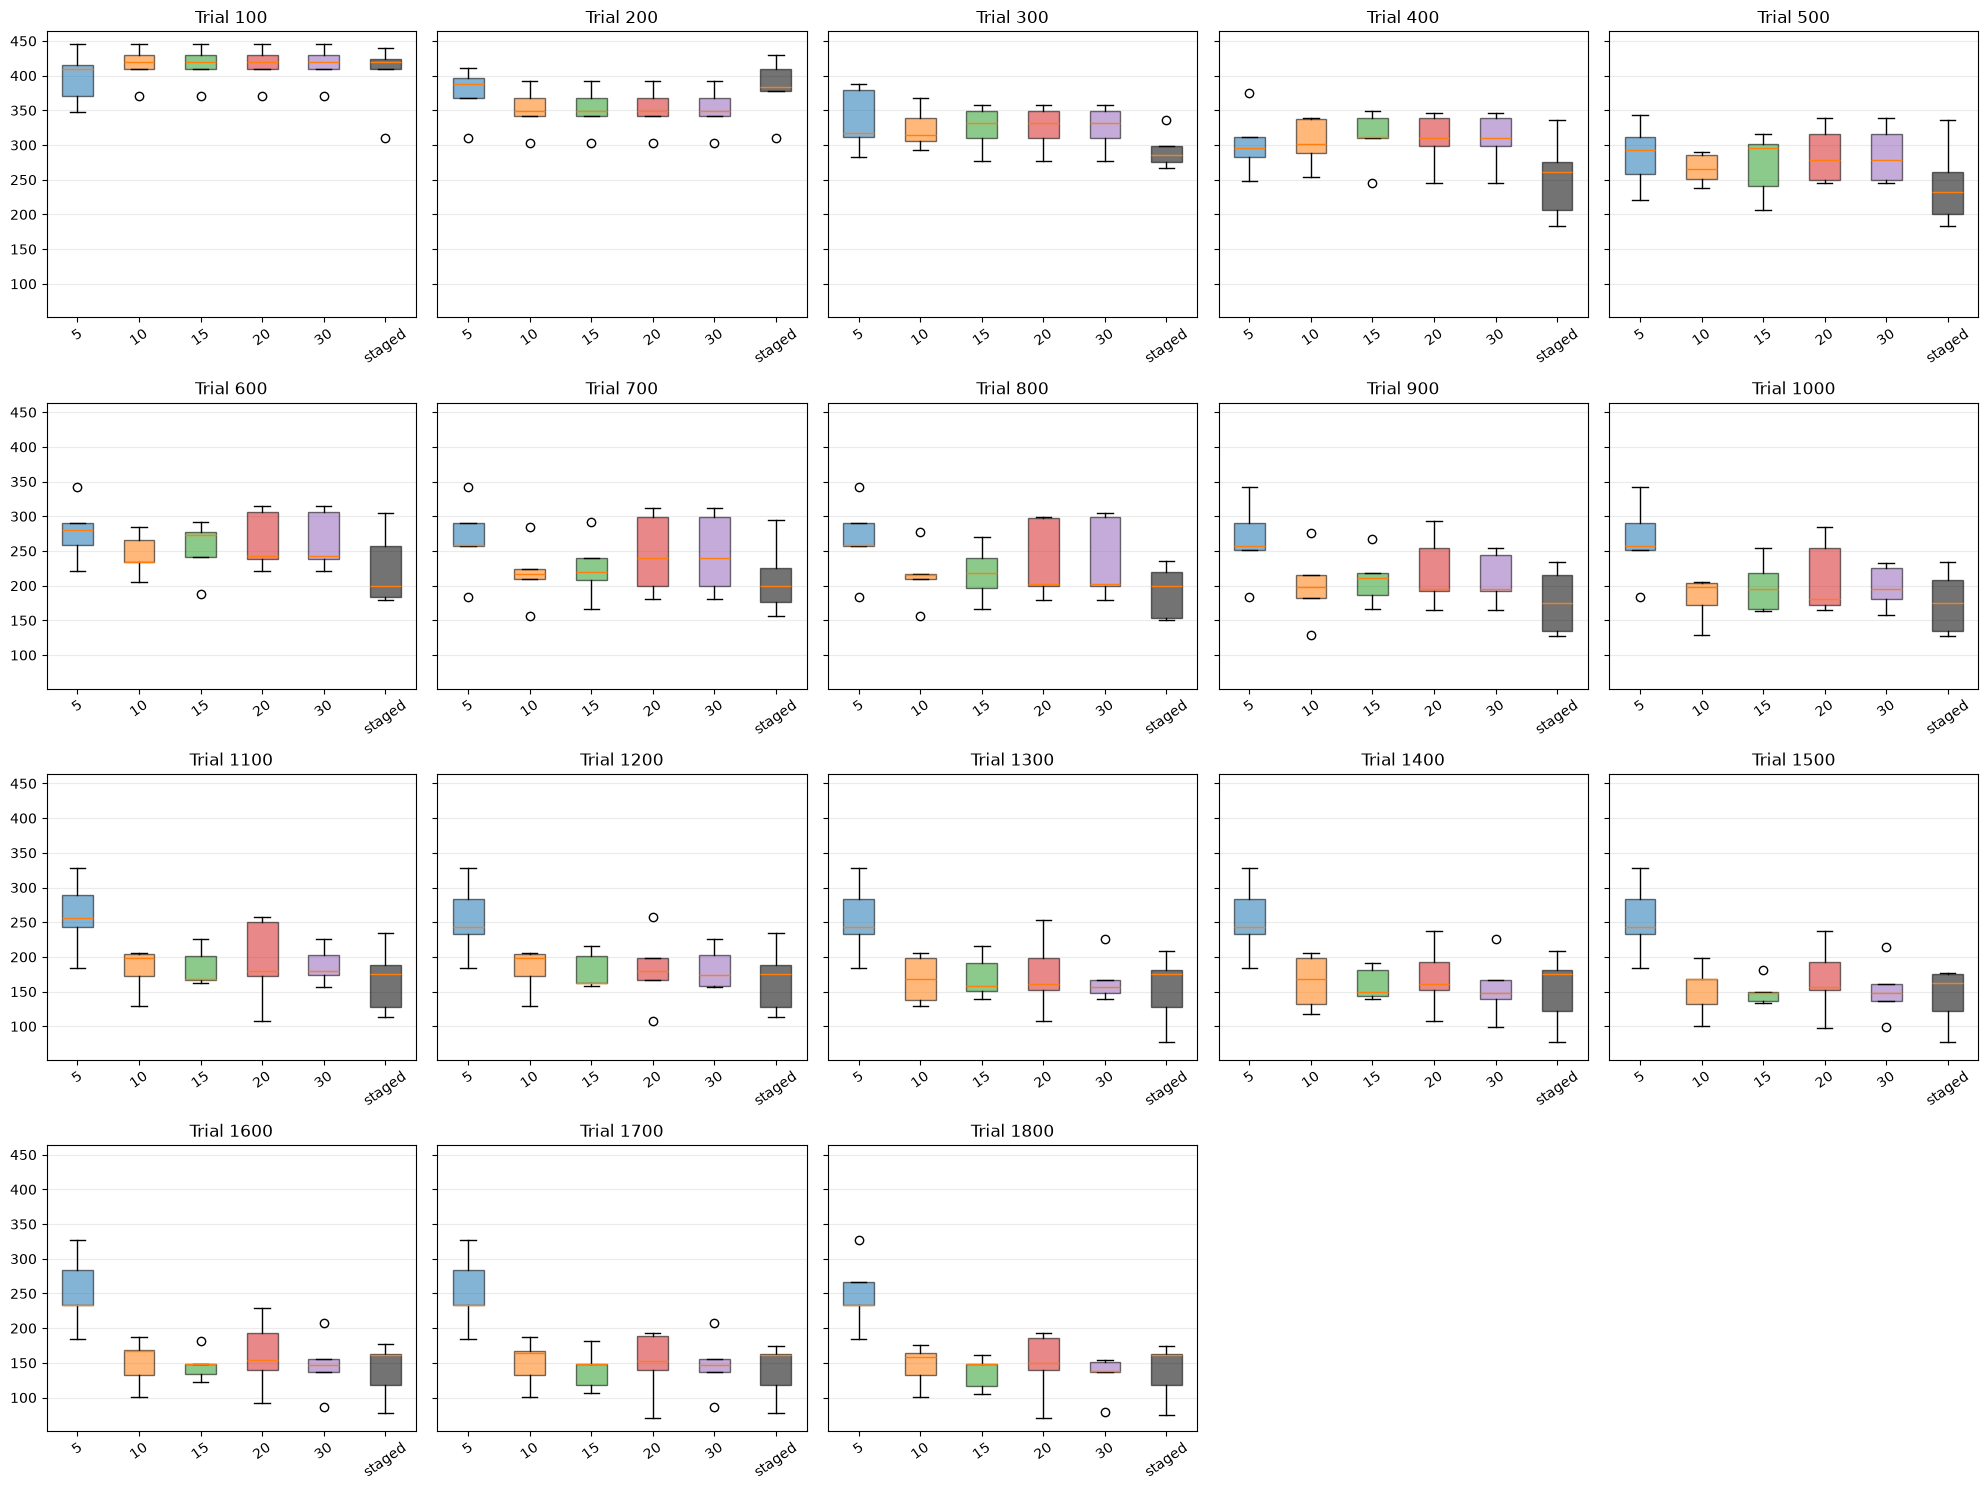

In [14]:
fig, axes = plt.subplots(4, 5, figsize=(20,15), sharey=True)
for ax, checkpoint in zip(axes.flat, CHECKPOINTS):
    values = [[results[p][s]["best_regret"][checkpoint-1] for s in SEEDS] for p in POLICIES]
    boxes = ax.boxplot(values, patch_artist=True, tick_labels=[str(d) for d in DEPTHS]+["staged"])
    for box,p in zip(boxes["boxes"],POLICIES): box.set(facecolor=COLORS[p],alpha=.55)
    ax.set_title(f"Trial {checkpoint}"); ax.tick_params(axis="x",rotation=35); ax.grid(axis="y",alpha=.25)
for ax in axes.flat[len(CHECKPOINTS):]: ax.set_visible(False)
plt.tight_layout(); plt.show()

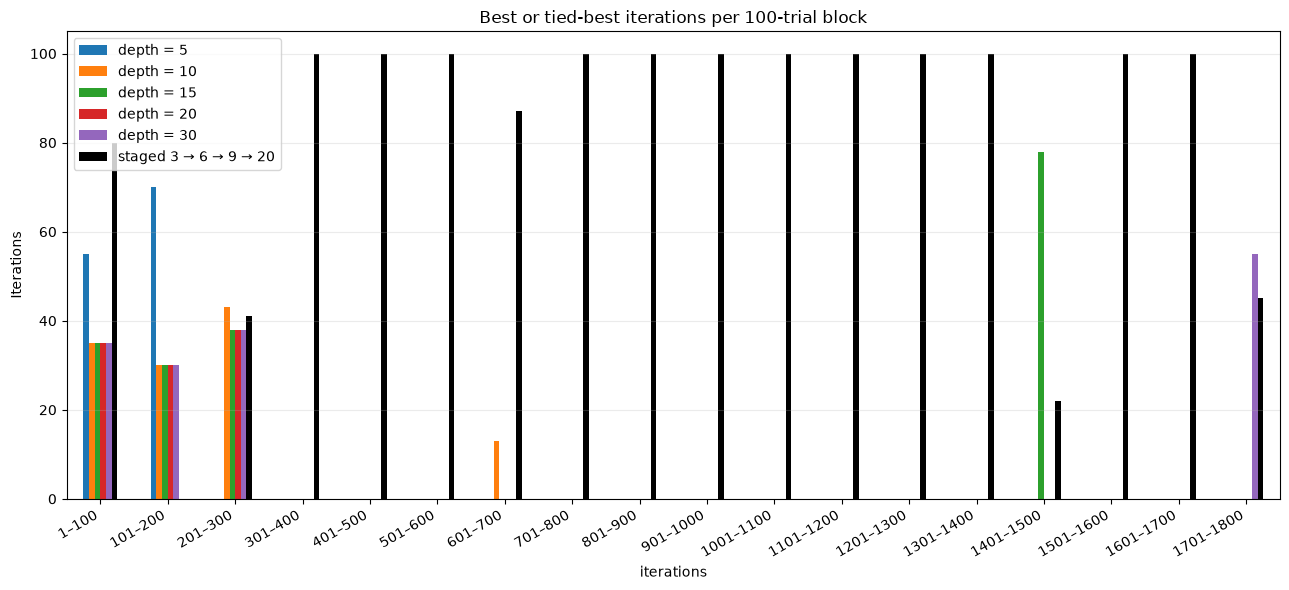

,iterations,superior policy,depth = 5,depth = 10,depth = 15,depth = 20,depth = 30,staged 3 → 6 → 9 → 20
0,1–100,staged 3 → 6 → 9 → 20,55,35,35,35,35,80
1,101–200,depth = 5,70,30,30,30,30,0
2,201–300,depth = 10,0,43,38,38,38,41
3,301–400,staged 3 → 6 → 9 → 20,0,0,0,0,0,100
4,401–500,staged 3 → 6 → 9 → 20,0,0,0,0,0,100
5,501–600,staged 3 → 6 → 9 → 20,0,0,0,0,0,100
6,601–700,staged 3 → 6 → 9 → 20,0,13,0,0,0,87
7,701–800,staged 3 → 6 → 9 → 20,0,0,0,0,0,100
8,801–900,staged 3 → 6 → 9 → 20,0,0,0,0,0,100
9,901–1000,staged 3 → 6 → 9 → 20,0,0,0,0,0,100


In [15]:
mean_regret = trajectories.pivot_table(index="iteration",columns="policy",values="best_regret",aggfunc="mean").reindex(columns=POLICIES)
best = mean_regret.min(axis=1)
wins = pd.DataFrame({p:np.isclose(mean_regret[p],best,rtol=1e-12,atol=1e-9) for p in POLICIES},index=mean_regret.index)
rows=[]
for end in CHECKPOINTS:
    counts=wins.loc[end-99:end].sum(); maximum=int(counts.max())
    row={"iterations":f"{end-99}–{end}","superior policy":", ".join(LABELS[p] for p in POLICIES if counts[p]==maximum)}
    row.update({LABELS[p]:int(counts[p]) for p in POLICIES}); rows.append(row)
block_superiority=pd.DataFrame(rows)
ax=block_superiority.set_index("iterations")[[LABELS[p] for p in POLICIES]].plot(kind="bar",figsize=(13,6),color=[COLORS[p] for p in POLICIES])
ax.set(title="Best or tied-best iterations per 100-trial block",ylabel="Iterations",ylim=(0,105)); ax.grid(axis="y",alpha=.25); plt.xticks(rotation=30,ha="right"); plt.tight_layout(); plt.show()
block_superiority

In [16]:
table = trajectories[trajectories.iteration.isin(CHECKPOINTS)].groupby(["iteration","policy"])["best_regret"].agg(["mean","std","min","median","max"])
with pd.option_context("display.max_rows",None,"display.max_columns",None,"display.width",None): display(table)

mean        std         min  \
iteration policy                                                     
100       fixed_depth_10         415.056555  27.741980  371.234294   
          fixed_depth_15         415.056555  27.741980  371.234294   
          fixed_depth_20         415.056555  27.741980  371.234294   
          fixed_depth_30         415.056555  27.741980  371.234294   
          fixed_depth_5          397.699657  38.672843  346.968125   
          staged_depth_3_6_9_20  400.795942  51.828224  310.154971   
200       fixed_depth_10         350.891638  33.456769  302.270081   
          fixed_depth_15         350.891638  33.456769  302.270081   
          fixed_depth_20         350.891638  33.456769  302.270081   
          fixed_depth_30         350.891638  33.456769  302.270081   
          fixed_depth_5          374.646340  39.469447  309.957940   
          staged_depth_3_6_9_20  382.336062  45.482923  310.154971   
300       fixed_depth_10         323.991882  29.846130  293.022318   
          fixed_depth_15         325.124062  32.517753  276.956570   
          fixed_depth_20         325.124062  32.517753  276.956570   
          fixed_depth_30         325.124062  32.517753  276.956570   
          fixed_depth_5          335.962566  45.823887  282.488987   
          staged_depth_3_6_9_20  292.428953  26.980257  266.848864   
400       fixed_depth_10         304.098182  35.530326  254.076105   
          fixed_depth_15         310.894235  40.679098  244.695284   
          fixed_depth_20         307.785535  40.326809  244.695284   
          fixed_depth_30         307.785535  40.326809  244.695284   
          fixed_depth_5          302.557314  47.173041  247.527428   
          staged_depth_3_6_9_20  252.345507  59.962006  183.039560   
500       fixed_depth_10         266.155648  21.779081  238.741220   
          fixed_depth_15         272.136690  46.126974  206.657317   
          fixed_depth_20         285.186485  41.019995  244.695284   
          fixed_depth_30         285.186485  41.019995  244.695284   
          fixed_depth_5          285.218852  47.416030  220.534002   
          staged_depth_3_6_9_20  242.735968  59.890488  183.039560   
600       fixed_depth_10         244.523135  31.015733  204.755790   
          fixed_depth_15         254.282181  41.470185  187.677997   
          fixed_depth_20         264.472244  42.947706  220.819412   
          fixed_depth_30         264.472244  42.947706  220.819412   
          fixed_depth_5          278.269513  44.810206  220.534002   
          staged_depth_3_6_9_20  224.853171  54.709590  179.372822   
700       fixed_depth_10         218.201280  45.718715  156.268422   
          fixed_depth_15         225.435044  45.549868  167.102266   
          fixed_depth_20         246.355840  57.948397  181.487151   
          fixed_depth_30         246.355840  57.948397  181.487151   
          fixed_depth_5          266.348202  57.670065  184.164517   
          staged_depth_3_6_9_20  210.312261  53.725478  155.753860   
800       fixed_depth_10         215.088115  43.125567  156.268422   
          fixed_depth_15         218.241736  39.693112  166.675905   
          fixed_depth_20         235.830879  57.821109  179.579709   
          fixed_depth_30         237.021222  59.462834  179.579709   
          fixed_depth_5          266.348202  57.670065  184.164517   
          staged_depth_3_6_9_20  191.692493  38.174739  150.732394   
900       fixed_depth_10         200.148880  52.899110  129.500577   
          fixed_depth_15         209.783409  37.917709  166.675905   
          fixed_depth_20         220.016296  52.353553  164.261324   
          fixed_depth_30         210.233027  37.807508  164.261324   
          fixed_depth_5          264.866485  58.021011  184.164517   
          staged_depth_3_6_9_20  177.171350  47.369162  127.570611   
1000      fixed_depth_10         182.165046  32.293719  129.500577   
          fixed_depth_15         199.573332  37.9